In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X, y = iris.data, iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [8]:

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 112
Testing samples: 38


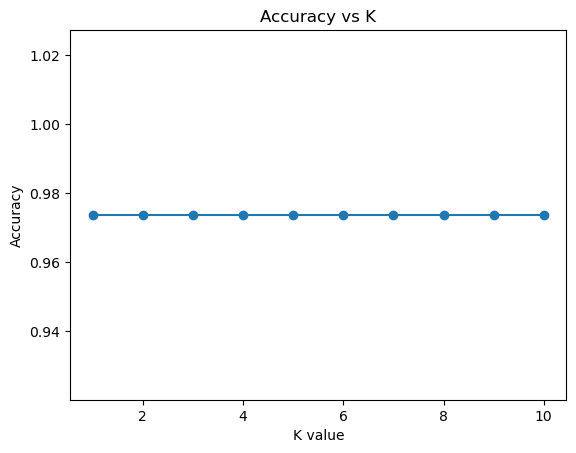

In [ ]:
import matplotlib.pyplot as plt

k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

In [4]:
# Euclidean (default)
knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_e = knn_euclidean.predict(X_test)

# Manhattan
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_m = knn_manhattan.predict(X_test)

print("Euclidean Accuracy:", accuracy_score(y_test, y_pred_e))
print("Manhattan Accuracy:", accuracy_score(y_test, y_pred_m))

Euclidean Accuracy: 0.9736842105263158
Manhattan Accuracy: 0.9736842105263158


In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split after scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print("Accuracy after normalization:", knn.score(X_test, y_test))

Accuracy after normalization: 1.0


In [6]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Without scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = knn_raw.score(X_test, y_test)

# With scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = knn_scaled.score(X_test_scaled, y_test)

print("Accuracy without scaling:", acc_raw)
print("Accuracy with scaling:", acc_scaled)

Accuracy without scaling: 0.7222222222222222
Accuracy with scaling: 0.9444444444444444


In [7]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"K = {k}, Accuracy = {acc}")

K = 3, Accuracy = 0.9298245614035088
K = 5, Accuracy = 0.956140350877193
K = 7, Accuracy = 0.956140350877193
